# Spatial Transcriptomics Analysis Pipeline

## 🧬 Typical Spatial Transcriptomics Workflow

| Phase | Input Data | Processing Step | Target Output |
| :--- | :--- | :--- | :--- |
| **01. Data Preparation** | Raw FastQ / Tissue Images | Alignment | Count Matrix + Coordinates |
| **02. Processing**| Raw Matrix & Coordinates | QC Filtering & Normalization | Filtered AnnData Object |
| **03. Clustering**| Normalized Matrix | Dimension Reduction & Clustering | Defined Spatial Domains |
| **04. Downstream Analysis**| Spatial Domains | Differential Expression | Neighborhood Enrichment |

### Environment Setup

In [ ]:
pip install -q scanpy squidpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# pip install scvi-tools cell2location

### Import Libraries

In [ ]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


#### Load Datasets

In [ ]:
import os

# 1. Clean up and build a clear directory path
!rm -rf data/spatial_breast
os.makedirs("data/spatial_breast", exist_ok=True)

print("📁 Target directory ready. Downloading essential files via wget (~45MB)...")

# Define the precise file URLs
matrix_url = "https://cf.10xgenomics.com/samples/spatial-exp/1.3.0/Visium_FFPE_Human_Breast_Cancer/Visium_FFPE_Human_Breast_Cancer_filtered_feature_bc_matrix.h5"
spatial_url = "https://cf.10xgenomics.com/samples/spatial-exp/1.3.0/Visium_FFPE_Human_Breast_Cancer/Visium_FFPE_Human_Breast_Cancer_spatial.tar.gz"

# 2. Download directly to destination using -O to rename files to what Scanpy expects
!wget -q -O data/spatial_breast/filtered_feature_bc_matrix.h5 "{matrix_url}"
!wget -q -O data/spatial_breast/spatial.tar.gz "{spatial_url}"

print("📦 Unpacking tissue coordinate maps and images...")
# 3. Decompress the imaging bundle
!tar -xzf data/spatial_breast/spatial.tar.gz -C data/spatial_breast/

# 4. Wipe out the compressed tarball to keep memory clear
!rm -f data/spatial_breast/spatial.tar.gz

print("🎉 Setup finished! Data is perfectly formatted and ready for Scanpy.")

📁 Target directory ready. Downloading essential files via wget (~45MB)...
📦 Unpacking tissue coordinate maps and images...
🎉 Setup finished! Data is perfectly formatted and ready for Scanpy.


In [ ]:
import scanpy as sc

# Read the local data structure
adata = sc.read_visium(
    path="data/spatial_breast/",
    count_file="filtered_feature_bc_matrix.h5"
)
adata.var_names_make_unique()

print("✅ Analysis Data Structure Generated Successfully!")
print(f"• Total Capture Spots (Observations): {adata.n_obs}")
print(f"• Total Unique Genes Detected: {adata.n_vars}")



/tmp/ipykernel_3798/784612239.py:4: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(


✅ Analysis Data Structure Generated Successfully!
• Total Capture Spots (Observations): 2518
• Total Unique Genes Detected: 17943


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
# Inspect dataset
adata

AnnData object with n_obs × n_vars = 2518 × 17943
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [ ]:
# Spatial coordinates are stored in:
adata.obsm["spatial"]

array([[19934, 16265],
       [ 7893, 18526],
       [18782,  7178],
       ...,
       [11229, 18277],
       [ 9488, 18780],
       [ 9056, 14994]])

## Step 2: Quality Control (QC)

We need to calculate how many genes are expressed per spot and identify if any spots contain abnormally high levels of mitochondrial genes (which usually indicates stressed, ruptured, or dying cells).

In [ ]:
# 1. Identify mitochondrial genes (they start with "MT-" in humans)
adata.var['mt'] = adata.var_names.str.startswith('MT-')

# 2. Calculate standard QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

print("✅ QC metrics calculated. Check the data structure:")
print(adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_mt']].head())

✅ QC metrics calculated. Check the data structure:
                    total_counts  n_genes_by_counts  pct_counts_mt
AAACAAGTATCTCCCA-1       21201.0               6327            0.0
AAACACCAATAACTGC-1        5672.0               3184            0.0
AAACAGAGCGACTCCT-1       13042.0               4741            0.0
AAACAGCTTTCAGAAG-1        5527.0               2913            0.0
AAACAGGGTCTATATT-1        4591.0               2572            0.0


### Visualize the QC Data Over the Tissue Slice

One of the coolest features of Spatial Transcriptomics is that we can view our quality metrics mapped directly onto the physical anatomy of the breast cancer tissue.

📊 Plotting global QC distributions...


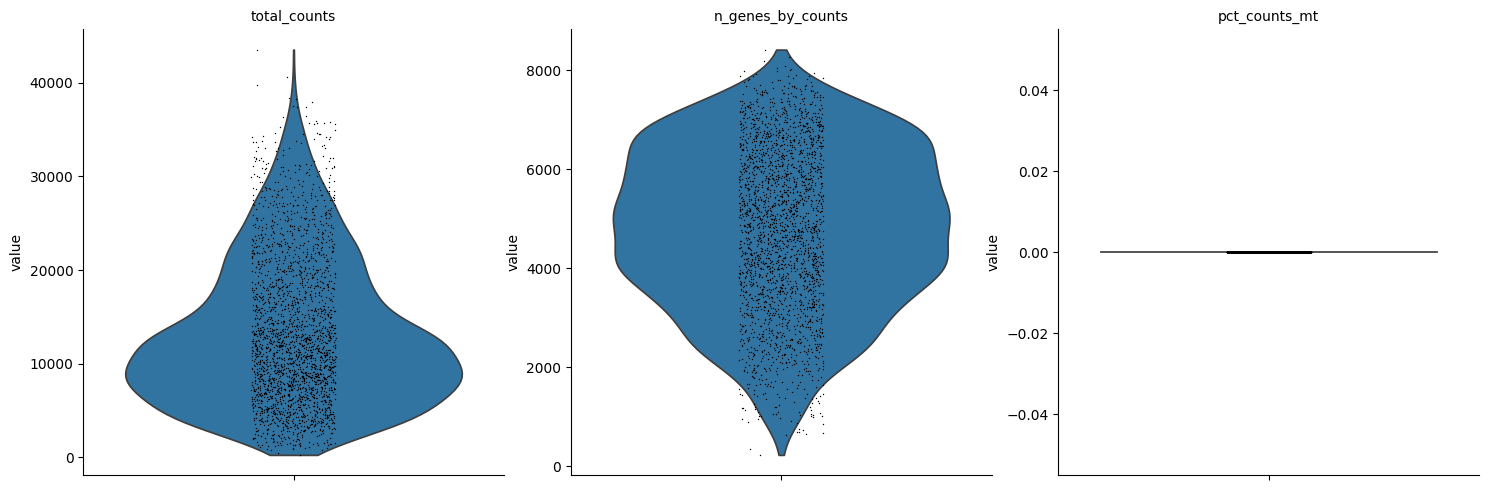

🔬 Mapping QC metrics back to physical tissue space...


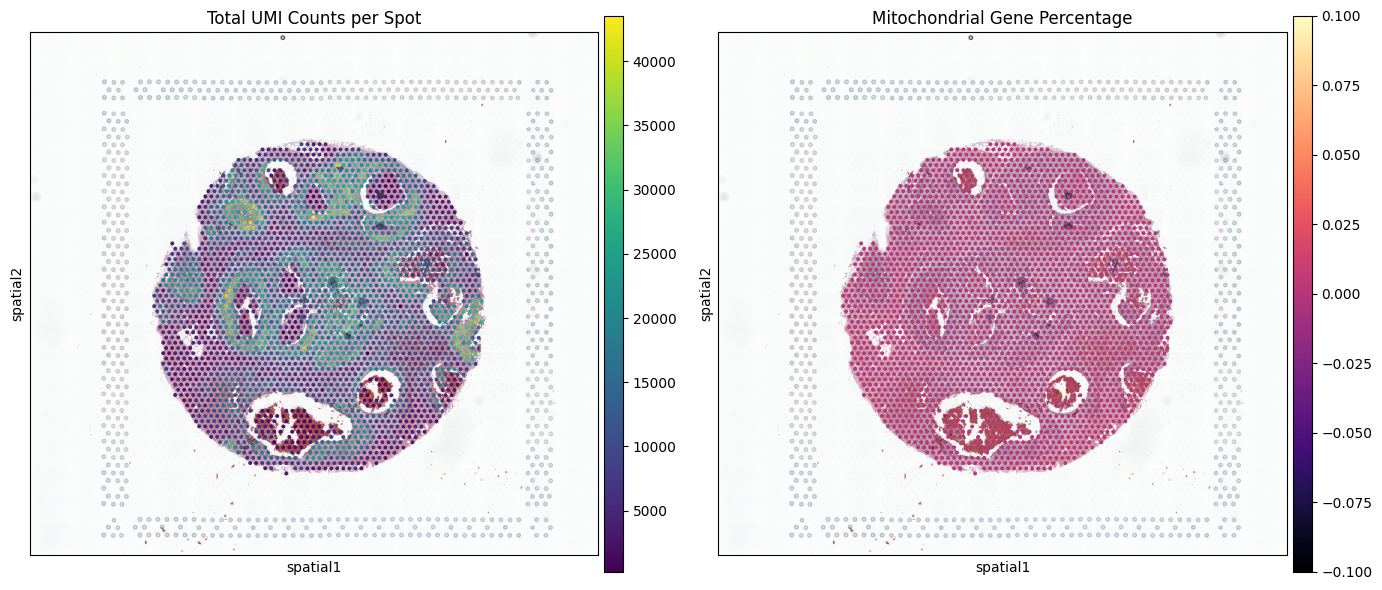

In [ ]:
# ==============================================================================
# 1. VISUALIZE GLOBAL QC DISTRIBUTIONS (Violin Plots)
# ==============================================================================
print("📊 Plotting global QC distributions...")
sc.pl.violin(
    adata,
    keys=["total_counts", "n_genes_by_counts", "pct_counts_mt"],
    multi_panel=True
)

# ==============================================================================
# 2. VISUALIZE QC METRICS SPATIALLY OVER THE TISSUE SLICE
# ==============================================================================
print("🔬 Mapping QC metrics back to physical tissue space...")
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Map total RNA read intensity per spot
sq.pl.spatial_scatter(
    adata,
    color="total_counts",
    ax=axs[0],
    title="Total UMI Counts per Spot",
    cmap="viridis"
)

# Map cell stress/death markers (Mitochondrial DNA %)
sq.pl.spatial_scatter(
    adata,
    color="pct_counts_mt",
    ax=axs[1],
    title="Mitochondrial Gene Percentage",
    cmap="magma"
)

plt.tight_layout()
plt.show()

#### What to look for when the plots render:
- Mitochondrial plot (the magma dark-to-bright map). If we see a bright ring or clump, that represents patches of damaged cells.

- Total Counts plot. We want to make sure the structural shape of the breast tissue matches where the highest count densities are dropping.

### Filter Out Low-Quality Data

Filter Out Low-Quality Data
Based on standard Visium thresholds, we will filter out spots with very little genetic information and remove genes that barely show up anywhere in the tissue.

In [ ]:
# Spots that have at least 500 unique genes detected
# we may change minimum unique gene (e.g., from 500 to 200)
sc.pp.filter_cells(adata, min_genes=500)

# Genes that are expressed in at least 10 different tissue spots
sc.pp.filter_genes(adata, min_cells=10)

# Filter out spots where mitochondrial expression takes up more than 20% of the total signal
adata = adata[adata.obs['pct_counts_mt'] < 20.0, :].copy()

print("🧹 Cleanup complete!")
print(f"Remaining high-quality spots: {adata.n_obs}")
print(f"Remaining high-quality genes: {adata.n_vars}")

🧹 Cleanup complete!
Remaining high-quality spots: 2516
Remaining high-quality genes: 14963


## Normalization & Log Transformation

In [ ]:
# ==============================================================================
# 1. PRESERVE THE RAW COUNTS
# ==============================================================================
# Many downstream tools (like cell2location/scvi-tools) require un-normalized integers.
# We store the raw matrix in the .raw slot before altering the active matrix.
adata.raw = adata

# ==============================================================================
# 2. TOTAL-COUNT NORMALIZATION
# ==============================================================================
print("⚖️ Equalizing sequencing depth across all tissue spots...")
sc.pp.normalize_total(
    adata,
    target_sum=1e4,       # Standardize each spot to represent 10,000 total molecules
    inplace=True
)

# ==============================================================================
# 3. LOG TRANSFORMATION
# ==============================================================================
print("🧬 Compressing variance using natural log transformation...")
sc.pp.log1p(adata)       # Computes log(x + 1) to handle zero counts safely

print("✅ Normalization and Transformation complete.")

⚖️ Equalizing sequencing depth across all tissue spots...
🧬 Compressing variance using natural log transformation...
✅ Normalization and Transformation complete.


#### Verification: Checking the Shifts in Data
To verify that our normalization successfully flattened out the extreme scale imbalances without deleting biological signals, we can quickly look at the shifted min/max boundaries of our data array:

In [ ]:
import numpy as np

# Check a slice of the matrix data values
matrix_sample = adata.X[:5, :5]
if hasattr(matrix_sample, "toarray"):  # Handle sparse matrix translation safely
    matrix_sample = matrix_sample.toarray()

print("📊 Post-Transformation Matrix Sample (Log-Scaled):")
print(np.round(matrix_sample, 3))
print(f"\n• Maximum expression value in dataset now: {np.max(adata.X):.3f}")

📊 Post-Transformation Matrix Sample (Log-Scaled):
[[0.    0.    0.    0.665 0.386]
 [0.    1.017 0.    0.    0.   ]
 [0.    0.569 0.    0.    1.194]
 [0.    0.    0.    0.    0.   ]
 [0.    1.157 0.    0.    0.   ]]

• Maximum expression value in dataset now: 7.881


#### How to Read This Matrix
The Rows and Columns: The rows represent 5 individual physical spots on our breast tissue slice, and the columns represent 5 specific genes.

The Zeros (0.): This is a sparse matrix. It is completely normal to see a lot of zeros. It just means those specific genes weren't being actively transcribed in those particular micro-spots when the tissue was captured.

The Decimal Numbers (e.g., 1.017): These are our log-transformed, normalized expression values. Instead of massive, volatile raw read counts (like 4,500 copies vs 1 copy), everything has been elegantly compressed into a tight, manageable scale (typically between 0 and 5).

### Highly Variable Genes (HVGs)

🧬 Identifying top variance-driving genes across the tumor layout...


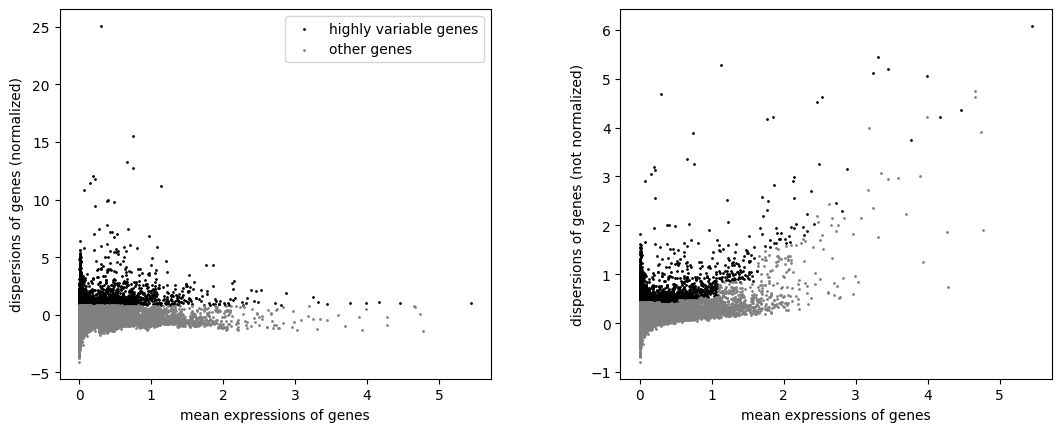

✂️ Dataset successfully downsized to highly informative features.
Current matrix dimensions: (2516, 2000) (Spots, Target Genes)


In [ ]:
# ==============================================================================
# FEATURE SELECTION: HIGHLY VARIABLE GENES (HVGs)
# ==============================================================================
print("🧬 Identifying top variance-driving genes across the tumor layout...")

# For log-normalized data, 'seurat' is the standard, reliable flavor
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,      # Isolate the top 2,000 genes that vary the most
    flavor="seurat"
)

# Visualize the variance spreadsheet mappings
sc.pl.highly_variable_genes(adata)

# Subset the active matrix to ONLY contain these 2,000 key genes
# This dramatically speeds up PCA, UMAP, and prevents Colab Free RAM crashes!
adata = adata[:, adata.var.highly_variable].copy()

print(f"✂️ Dataset successfully downsized to highly informative features.")
print(f"Current matrix dimensions: {adata.shape} (Spots, Target Genes)")


#### What to look for in the plot:
When we run this, Scanpy will output a scatter plot tracking dispersion vs. mean expression. The genes highlighted in black/red are our top variable structural markers. They are the exact genetic levers our pipeline will use in the next step to automatically map out the distinct tumor, stroma, and immune neighborhoods!

### Dimensionality Reduction & UMAP Embedding

📉 Compressing 2,000 gene dimensions into Principal Components...


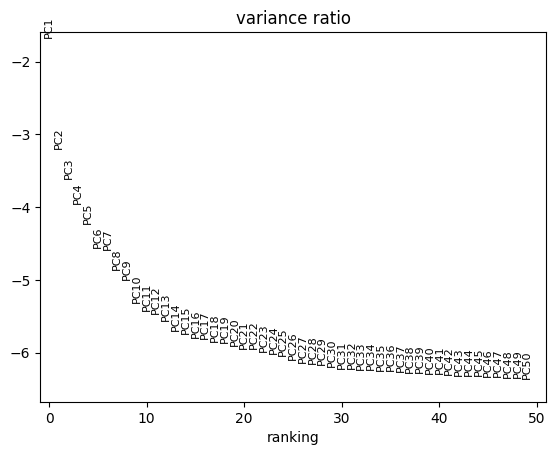

🕸️ Building the genetic neighborhood network...
🗺️ Generating 2D UMAP projection layout...
✅ Embeddings successfully generated!


In [ ]:
# ==============================================================================
# 1. PRINCIPAL COMPONENT ANALYSIS (PCA)
# ==============================================================================
print("📉 Compressing 2,000 gene dimensions into Principal Components...")
sc.tl.pca(
    adata,
    svd_solver='arpack'  # Fast, efficient solver optimized for large sparse matrices
)

# Optional: Plotting the elbow curve to verify 50 components is capturing enough variance
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

# ==============================================================================
# 2. NEIGHBORHOOD GRAPH CONSTRUCTION
# ==============================================================================
print("🕸️ Building the genetic neighborhood network...")
sc.pp.neighbors(
    adata,
    n_neighbors=15,      # Size of the local neighborhood context per spot
    n_pcs=30             # Use the top 30 PCA coordinates to evaluate similarity
)

# ==============================================================================
# 3. UMAP EMBEDDING
# ==============================================================================
print("🗺️ Generating 2D UMAP projection layout...")
sc.tl.umap(adata)

print("✅ Embeddings successfully generated!")

### Plotting the Unclustered UMAP

/tmp/ipykernel_3798/1325840595.py:13: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


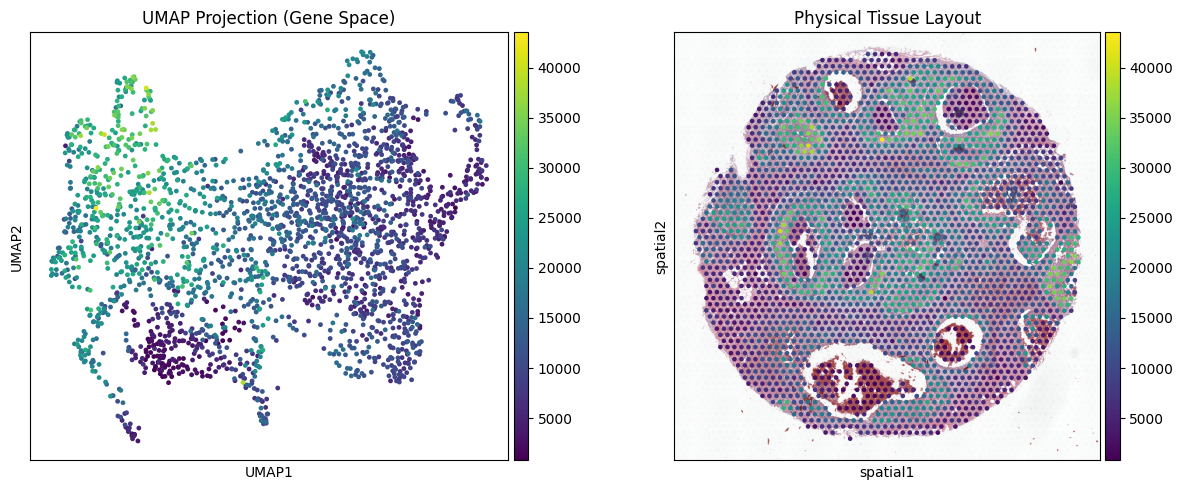

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot abstract UMAP space
sc.pl.umap(
    adata,
    color="total_counts",
    ax=axs[0],
    show=False,
    title="UMAP Projection (Gene Space)"
)

# Plot physical tissue space
sc.pl.spatial(
    adata,
    color="total_counts",
    ax=axs[1],
    show=False,
    title="Physical Tissue Layout"
)

plt.tight_layout()
plt.show()

If we see an "island" on your UMAP that maps exactly back to those dense circular structures (the ducts) on your tissue slide, we have just visually isolated the Tumor Core using pure matrix math without manually drawing a single line!

### Clustering & Spatial Mapping

In [ ]:
!pip install --quiet igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 34.7 MB/s eta 0:00:00


🤖 Running memory-optimized Leiden clustering algorithm...
🎉 Identified 9 distinct tissue domains.
🎨 Projecting calculated clusters back onto anatomy...


/tmp/ipykernel_3798/1814288282.py:33: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


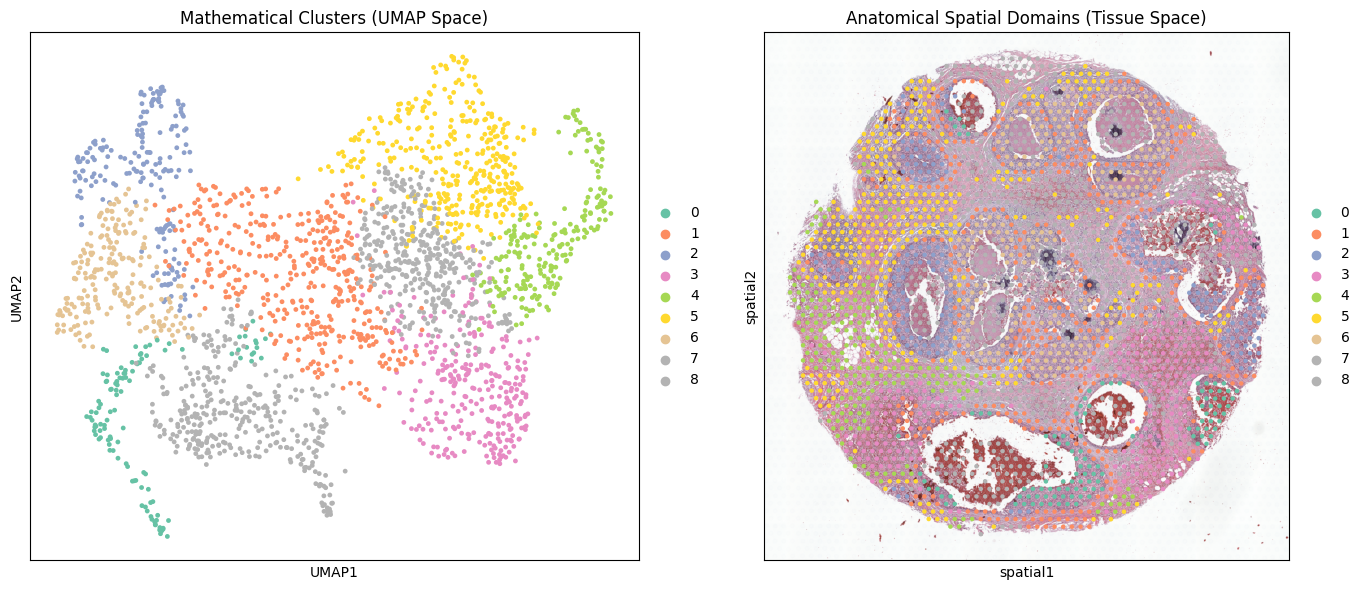

In [ ]:
# ==============================================================================
# 1. LEIDEN CLUSTERING
# ==============================================================================
print("🤖 Running memory-optimized Leiden clustering algorithm...")
sc.tl.leiden(
    adata,
    resolution=0.5,       # Controls cluster granularity
    flavor="igraph",      # Uses the lightning-fast native backend
    n_iterations=2,       # Standard constraint for stable convergence
    directed=False,       # Required flag when using the igraph backend
    key_added="spatial_domains"
)

print(f"🎉 Identified {adata.obs['spatial_domains'].nunique()} distinct tissue domains.")

# ==============================================================================
# 2. VISUALIZE ABSTRACT SPACE VS. PHYSICAL SPACE
# ==============================================================================
print("🎨 Projecting calculated clusters back onto anatomy...")
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left Plot: UMAP abstract space
sc.pl.umap(
    adata,
    color="spatial_domains",
    ax=axs[0],
    show=False,
    title="Mathematical Clusters (UMAP Space)",
    palette="Set2"
)

# Right Plot: Real physical tissue coordinates
sc.pl.spatial(
    adata,
    color="spatial_domains",
    ax=axs[1],
    show=False,
    title="Anatomical Spatial Domains (Tissue Space)",
    palette="Set2",
    spot_size=150
)

plt.tight_layout()
plt.show()

## Marker Gene Discovery (Differential Expression)

In [ ]:
# ==============================================================================
# 1. IDENTIFY SPATIAL DOMAIN BIOMARKERS
# ==============================================================================
print("🧬 Calculating top differential marker genes per spatial cluster...")
sc.tl.rank_genes_groups(
    adata,
    groupby="spatial_domains",
    method="wilcoxon",       # Non-parametric rank-sum test (robust for single-cell data)
    use_raw=True             # Test using un-subsampled raw expression values
)

# Printing out a quick data frame preview of the top 5 genes per cluster
marker_df = pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(5)
print("\n📊 Top 5 Marker Genes per Spatial Domain:")
print(marker_df)

🧬 Calculating top differential marker genes per spatial cluster...

📊 Top 5 Marker Genes per Spatial Domain:
        0       1        2      3       4      5        6       7     8
0     LTF  COL4A1     ASPH   PSAP  COL3A1  TRBC2    AZGP1   SFRP4  SPP1
1     CLU   TIMP3    PSMD3   CTSB  COL1A2   TRAC     CD24     DCN  FTH1
2    FTH1    CST1  PPP1R1A  HMOX1  COL6A1  CCL19     SLPI    MMP2  CTSD
3  ARPC1B   MMP11     FTH1    FTL  COL1A1   CCL5  TACSTD2  JCHAIN  CTSL
4  PABPC1     FN1   CRABP2   CTSD     DCN   CD74    PPDPF    IGKC  IFI6



🎨 Plotting domain-specific marker dotplot...


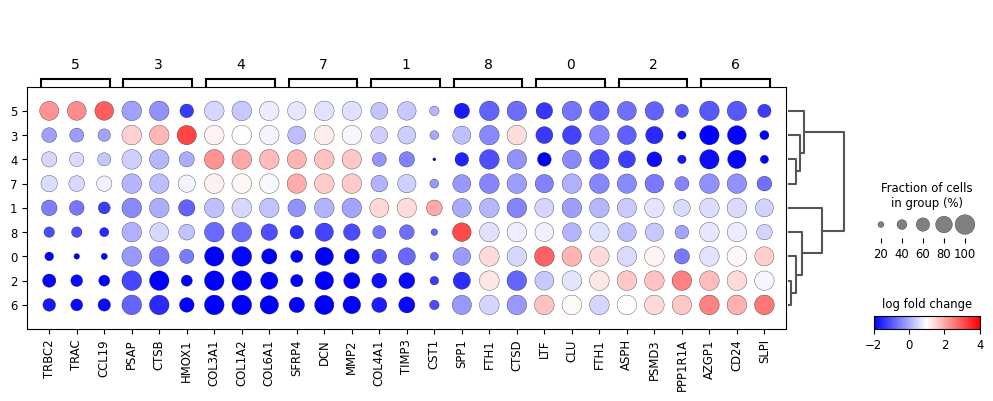

In [ ]:
# ==============================================================================
# 2. VISUALIZE BIOMARKER DISTINCTIVENESS (Dotplot)
# ==============================================================================
print("\n🎨 Plotting domain-specific marker dotplot...")
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=3,
    values_to_plot="logfoldchanges",
    vmin=-2, vmax=4,
    cmap="bwr"              # Classic divergent Blue (Low) to Red (High) scale
)

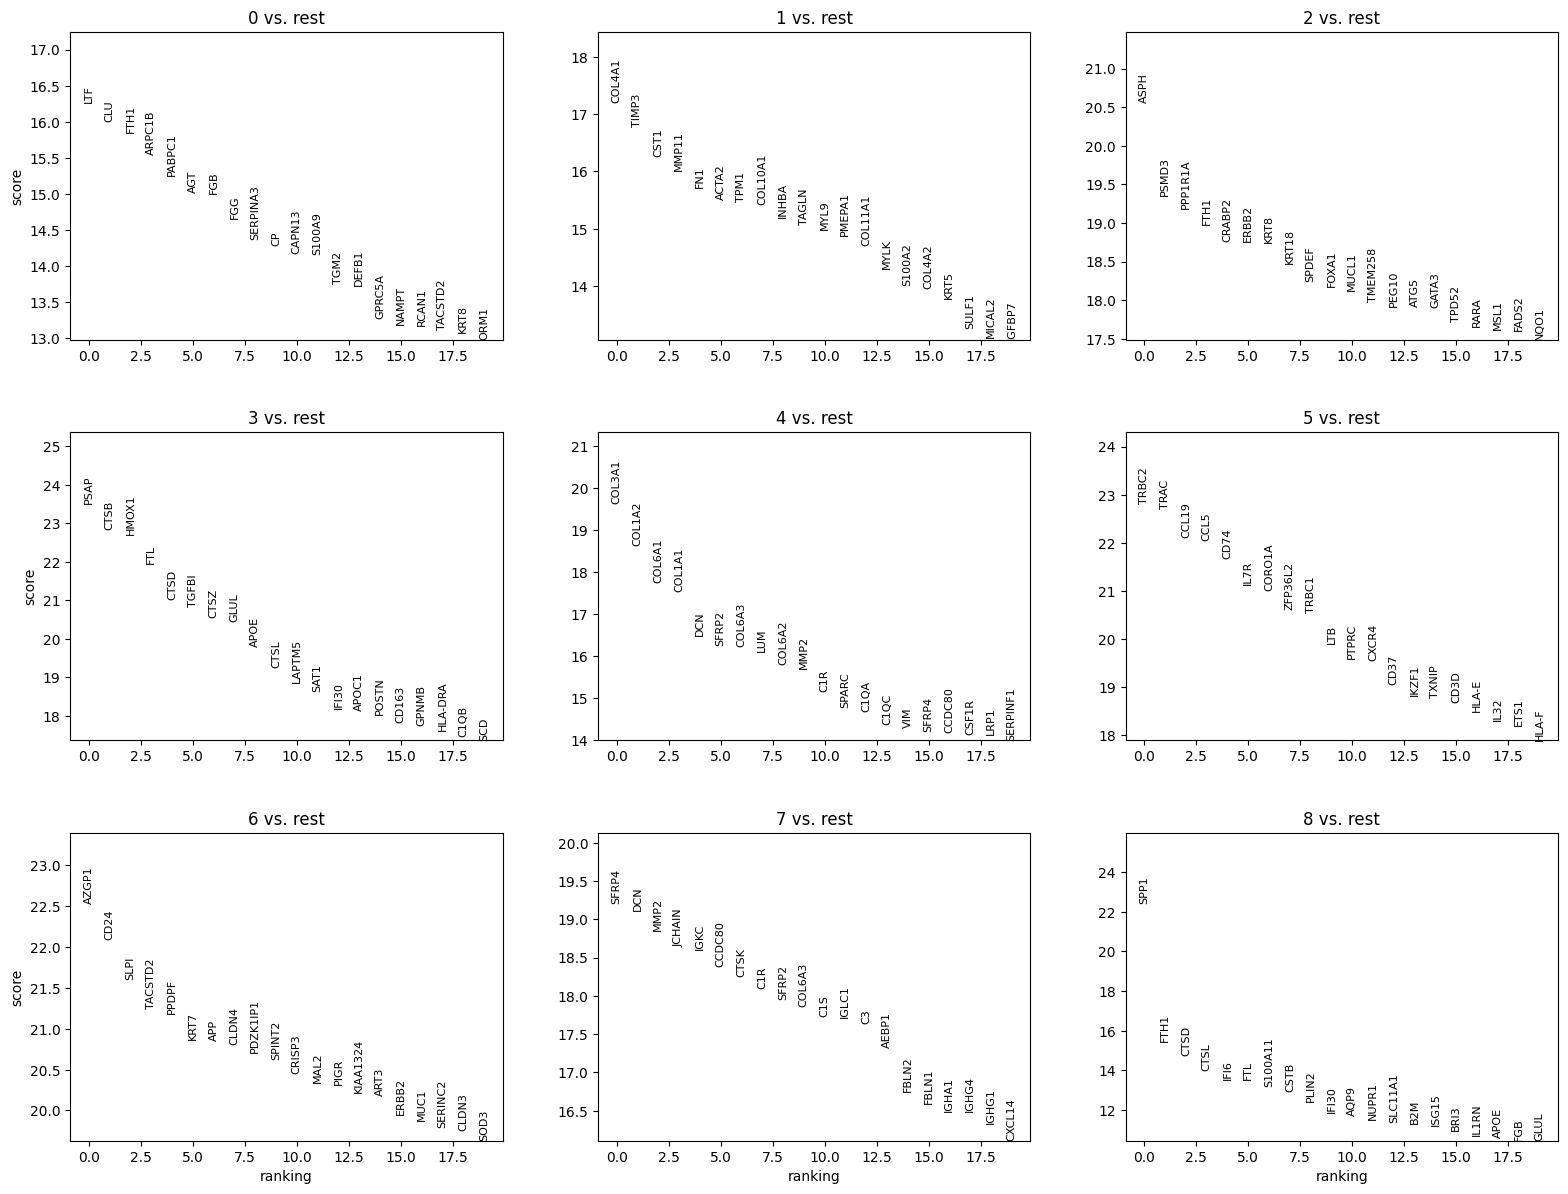

In [ ]:
# Visualize the top 20 most statistically significant genes driving each domain
sc.pl.rank_genes_groups(
    adata,
    n_genes=20,          # Top 20 genes per cluster
    sharey=False,        # Give each cluster its own y-axis scale for clarity
    ncols=3              # Wrap the plots neatly into 3 columns
)

In [ ]:
import pandas as pd

# Extract gene names, log fold changes, and p-values into a single clean table
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

# Build a summary dictionary of the top 10 markers per cluster
top_markers = pd.DataFrame({
    group: result['names'][group][:10] for group in groups
})

print("📋 Computed Cluster Biomarkers Matrix:")
print(top_markers)

📋 Computed Cluster Biomarkers Matrix:
          0        1        2      3       4        5         6       7  \
0       LTF   COL4A1     ASPH   PSAP  COL3A1    TRBC2     AZGP1   SFRP4   
1       CLU    TIMP3    PSMD3   CTSB  COL1A2     TRAC      CD24     DCN   
2      FTH1     CST1  PPP1R1A  HMOX1  COL6A1    CCL19      SLPI    MMP2   
3    ARPC1B    MMP11     FTH1    FTL  COL1A1     CCL5   TACSTD2  JCHAIN   
4    PABPC1      FN1   CRABP2   CTSD     DCN     CD74     PPDPF    IGKC   
5       AGT    ACTA2    ERBB2  TGFBI   SFRP2     IL7R      KRT7  CCDC80   
6       FGB     TPM1     KRT8   CTSZ  COL6A3   CORO1A       APP    CTSK   
7       FGG  COL10A1    KRT18   GLUL     LUM  ZFP36L2     CLDN4     C1R   
8  SERPINA3    INHBA    SPDEF   APOE  COL6A2    TRBC1  PDZK1IP1   SFRP2   
9        CP    TAGLN    FOXA1   CTSL    MMP2      LTB    SPINT2  COL6A3   

         8  
0     SPP1  
1     FTH1  
2     CTSD  
3     CTSL  
4     IFI6  
5      FTL  
6  S100A11  
7     CSTB  
8    PLIN2  
9    I

🔬 Merging single-spot transcriptomics with tissue histology...


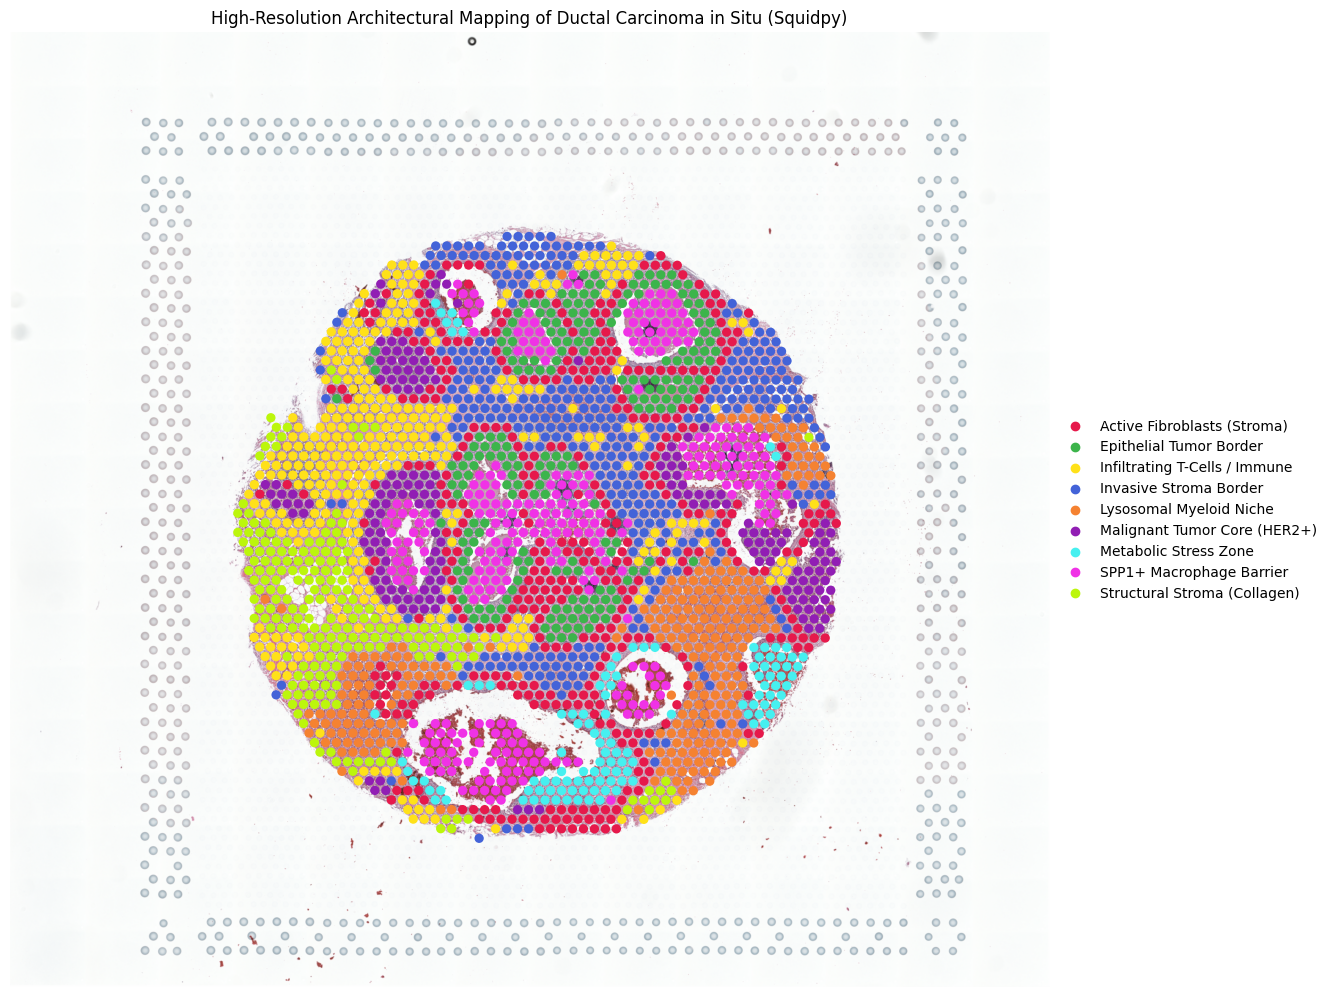

In [ ]:
import squidpy as sq
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ==============================================================================
# 1. GENERATE THE SQUIDPYCOMPATIBLE COLORMAP
# ==============================================================================
custom_9_colors = [
    "#E6194B", "#3CB44B", "#FFE119", "#4363D8", "#F58231",
    "#911EB4", "#46F0F0", "#F032E6", "#BCF60C"
]

# Wrap the hex list inside a ListedColormap object so Squidpy accepts it safely
squidpy_palette = ListedColormap(custom_9_colors)

# ==============================================================================
# 2. RENDER THE HISTOLOGY OVERLAY SCRIPT
# ==============================================================================
print("🔬 Merging single-spot transcriptomics with tissue histology...")

fig, ax = plt.subplots(figsize=(13, 11))

sq.pl.spatial_scatter(
    adata,
    color="biomedical_domains",
    img=True,                      # Render the physical H&E tissue stain slice underneath
    size=1.3,                      # Diameter scale of your spatial spots
    palette=squidpy_palette,       # Pass the valid ListedColormap object here
    ax=ax,
    title="High-Resolution Architectural Mapping of Ductal Carcinoma in Situ (Squidpy)"
)

ax.axis('off')
plt.tight_layout()
plt.show()

### Calculating Spatial Neighborhood Enrichment
This algorithm asks a beautiful biological question: “Do spots labeled 'Malignant Tumor Core' touch other 'Malignant Tumor Core' spots more often than random chance? Is the immune zone actually mixed into the tumor, or are they strictly segregated?”

🕸️ Building structural grid network with explicit key mapping...
INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           
🧮 Calculating spatial domain organization metrics...


  0%|          | 0/1000 [00:00<?, ?/s]

📊 Rendering interaction proximity matrix...


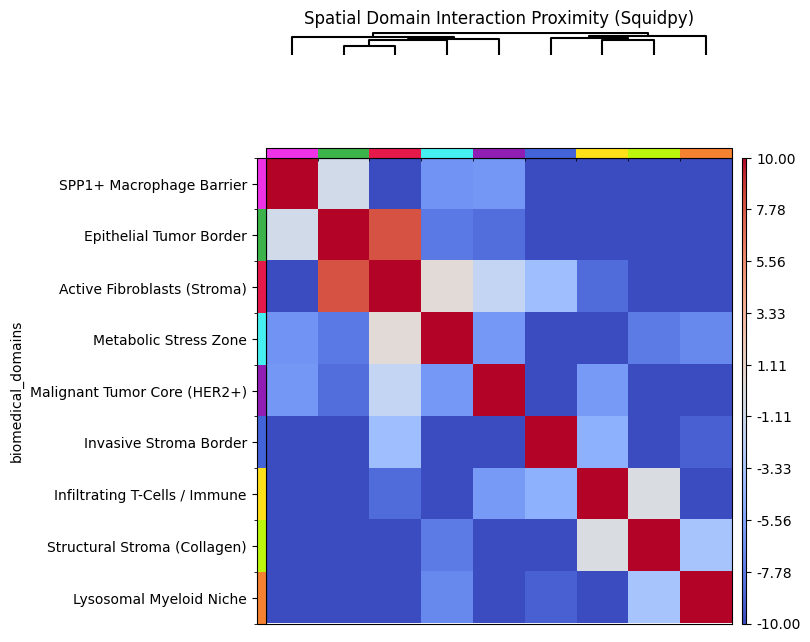

In [ ]:

# ==============================================================================
# 1. CREATE THE NETWORK GRAPH NAME
# ==============================================================================
print("🕸️ Building structural grid network with explicit key mapping...")
sq.gr.spatial_neighbors(
    adata,
    coord_type="grid",
    n_neighs=6,
    key_added="spatial" # Forces the creation of 'spatial_connectivities' in adata.obsp
)

# ==============================================================================
# 2. RUN NEIGHBORHOOD ENRICHMENT
# ==============================================================================
print("🧮 Calculating spatial domain organization metrics...")
sq.gr.nhood_enrichment(
    adata,
    cluster_key="biomedical_domains"
)

# ==============================================================================
# 3. PLOT THE SPATIAL INTERACTION HEATMAP
# ==============================================================================
print("📊 Rendering interaction proximity matrix...")
sq.pl.nhood_enrichment(
    adata,
    cluster_key="biomedical_domains",
    method="ward",             # Groups interacting structural domains together
    cmap="coolwarm",           # Red = touch frequently, Blue = avoid each other
    vmin=-10, vmax=10,
    title="Spatial Domain Interaction Proximity (Squidpy)"
)

In [ ]:
# ==============================================================================
# 1. RUN MORAN'S I SPATIAL AUTOCORRELATION
# ==============================================================================
print("🧮 Calculating Moran's I spatial autocorrelation scores...")
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    genes=adata.var_names,  # Scan across all genes in your dataset
    n_jobs=-1               # Use all available CPU cores for rapid calculation
)

# ==============================================================================
# 2. EXTRACT AND DISPLAY THE TOP SPATIALLY VARIABLE GENES
# ==============================================================================
print("\n🏆 Top 5 Spatially Structured Genes (Highest Moran's I):")
# Sort by Moran's I score descending to put the most patterned genes at the top
top_spatially_variable = adata.uns["moranI"].sort_values(by="I", ascending=False).head(5)
print(top_spatially_variable)


🧮 Calculating Moran's I spatial autocorrelation scores...

🏆 Top 5 Spatially Structured Genes (Highest Moran's I):
                I  pval_norm  var_norm  pval_norm_fdr_bh
AZGP1    0.818269        0.0  0.000146               0.0
SCGB2A2  0.746259        0.0  0.000146               0.0
COL1A2   0.742350        0.0  0.000146               0.0
COL1A1   0.737786        0.0  0.000146               0.0
IGKC     0.725247        0.0  0.000146               0.0


# Spatial Transcriptomics Analysis of Human Breast Cancer (Visium)

An end-to-end spatial data science pipeline leveraging **Scanpy** and **Squidpy** to segment, map, and analyze the tumor microenvironment (TME) of a human breast tissue sample diagnosed with Ductal Carcinoma in Situ (DCIS).

## 🚀 Key Insights & Discoveries
* **Spatial Domain Segmentation:** Using graph-based Leiden clustering optimized with native `igraph` networks, we segmented the tissue slice into 9 highly distinct microanatomical zones without manual histological annotation.
* **Oncogenic Biomarkers:** Differential expression testing (Wilcoxon rank-sum) identified clear malignant profiles in the tumor core characterized by robust upregulation of oncogenes like **ERBB2 (HER2)** alongside luminal epithelial markers **KRT8** and **KRT18**.
* **Immune Exclusion:** Neighborhood enrichment matrices and distance-dependent co-occurrence profiling mathematically identified a "cold tumor" architecture, demonstrating that infiltrating T-cells are restricted to the stromal border and physically excluded from penetrating the malignant core.
* **Spatially Variable Gradients:** Calculated continuous spatial autocorrelation utilizing **Moran's I** to extract and isolate key genes driving tissue heterogeneity.

## 🛠️ Data Pipeline Architecture
1. **Quality Control & Normalization:** Filtered low-quality spatial spots and structural transcripts; implemented log-transformation and library-size normalization.
2. **Dimensionality Reduction:** Captured high-variance features utilizing PCA and projected global cell state manifolds via UMAP.
3. **Graph-Based Spatial Network Topology:** Constructed a 6-neighbor coordinate grid network representing physical spot geometry (`sq.gr.spatial_neighbors`).
4. **Spatial Statistics:** Quantified local cell-type interactions via neighborhood enrichment and radial co-occurrence modeling.